In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

In [12]:
df = pd.read_csv("out.csv", names=["a"])

In [14]:
df.head

<bound method NDFrame.head of               a
0      1.000000
1      1.633348
2      1.479675
3      1.089249
4      1.201168
...         ...
99995  2.161019
99996  1.280277
99997  2.403928
99998  1.260340
99999  1.287870

[100000 rows x 1 columns]>

(array([9.9825e+04, 1.2400e+02, 2.4000e+01, 1.2000e+01, 6.0000e+00,
        1.0000e+00, 2.0000e+00, 2.0000e+00, 2.0000e+00, 1.0000e+00]),
 array([  1.000002 ,  24.6618418,  48.3236816,  71.9855214,  95.6473612,
        119.309201 , 142.9710408, 166.6328806, 190.2947204, 213.9565602,
        237.6184   ]),
 <BarContainer object of 10 artists>)

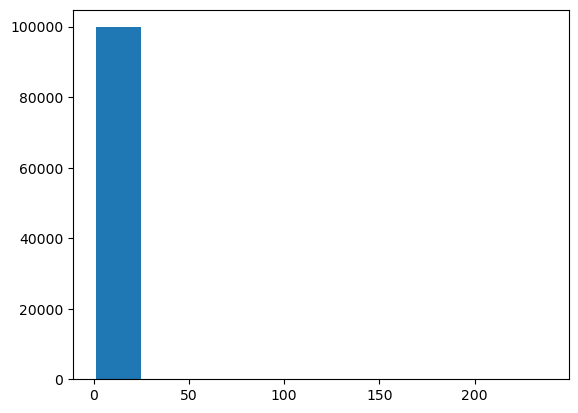

In [8]:
plt.hist(df)

In [9]:


def loglog_hist(series: pd.Series, bins=50, **kwargs):
    """
    Plot a histogram of a pandas Series on a log-log scale with log-spaced bins.

    Parameters
    ----------
    series : pd.Series
        Input data. Only positive entries are used.
    bins : int or sequence, default=50
        If int, creates that many bins equally spaced on a logarithmic scale.
        If sequence, uses the given bin edges (assumed appropriate for log scale).
    **kwargs : additional keyword arguments
        Passed to matplotlib.pyplot.hist (e.g., alpha, color, edgecolor).

    Returns
    -------
    None
        Displays the plot.
    """
    # Drop missing values
    data = series.dropna()

    # Keep only positive values (log scale requires x > 0)
    positive_data = data[data > 0]
    if len(positive_data) < len(data):
        warnings.warn(f"Dropped {len(data) - len(positive_data)} non-positive values "
                      f"({len(positive_data)} remain)")

    if len(positive_data) == 0:
        raise ValueError("No positive data points left after filtering. Cannot plot log-log histogram.")

    # Determine bin edges
    if isinstance(bins, int):
        # Create bins equally spaced on a logarithmic scale
        log_min = np.log10(positive_data.min())
        log_max = np.log10(positive_data.max())
        bin_edges = np.logspace(log_min, log_max, bins + 1)
    else:
        # Use user-supplied bins (assumed suitable for log scale)
        bin_edges = bins

    # Plot histogram with log-spaced bins (linear counts)
    plt.hist(positive_data, bins=bin_edges, **kwargs)

    # Set both axes to logarithmic scale
    plt.xscale('log')
    plt.yscale('log')

    # Labels and title
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title('Histogram (log-log scale with log-spaced bins)')

    plt.show()

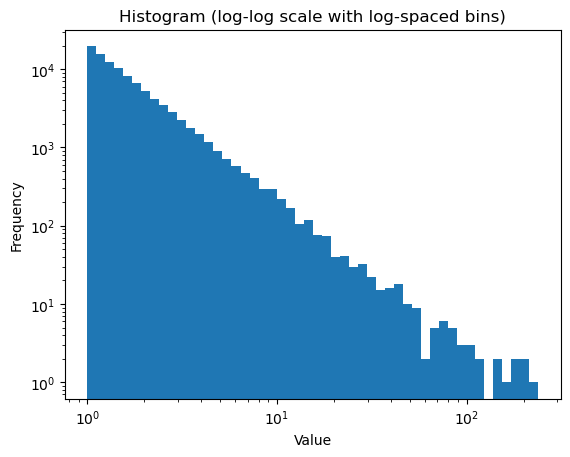

In [17]:
loglog_hist(df.a)